# Example using an ROI

In [1]:
%matplotlib widget

### Importing utils

In [2]:
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.path import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import cKDTree
from pyiconeus import open_path, Scan, Bps, Roi
from pyiconeus.utils.utils import transform_points_forward
from pyiconeus.models.Roi import RoiElements
from ipywidgets import *

# Scan loading and setup

### Loading the scan

In [3]:
scan: Scan = open_path("D:\demoBPS\scanFile4DScan.scan")
voxels = scan.voxels
voxels.shape
norm_voxels = voxels

# Bps loading and adding to the scan

In [4]:
bps: Bps = open_path("D:\demoBPS\scanFile4DScan.bps")
bps.data

array([[ 3.80807955e-04,  3.76379666e-03, -4.03573098e-04,
        -7.85258834e-03],
       [-3.78118791e-03,  3.97283254e-04,  1.37241420e-04,
        -9.22290793e-03],
       [ 1.77917094e-04,  3.87365409e-04,  3.78052176e-03,
        -5.25203170e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [5]:
scan.bps = bps

# Utils function to display the ROI volume

In [6]:
def _to_row_major(arr, n_cols=3):
    """
    Normalize to shape (n, n_cols) regardless of whether the source array was
    stored as (n_cols, n) or (n, n_cols). Diagnosis: roi.vertices / roi.faces
    from pyiconeus turned out to be (n, 3) already (n rows, one per
    vertex/face), NOT (3, n) as originally assumed -- so a blind `.T` was
    transposing correctly-shaped data into the wrong shape, causing vertex
    indices to be looked up on the coordinate axis (size 3) instead of the
    vertex axis (size n), hence "index 4 is out of bounds for axis 0 with
    size 3".
    """
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape {arr.shape}")
    if arr.shape[0] == n_cols and arr.shape[1] != n_cols:
        return arr.T
    return arr


In [7]:
def volume(roi: RoiElements):
    """
    Mesh volume via the divergence theorem: sum the signed volume of the
    tetrahedron formed by each face and the origin.
    """
    v = _to_row_major(roi.vertices)
    f = _to_row_major(roi.faces).astype(int)
    v0, v1, v2 = v[f[:, 0]], v[f[:, 1]], v[f[:, 2]]
    signed_vols = np.einsum('ij,ij->i', v0, np.cross(v1, v2))
    return abs(signed_vols.sum()) / 6.0


In [8]:
def slice_contour(roi: RoiElements, coord, axis=1):
        """
        Intersect the mesh with the plane {axis-th coordinate == coord} and
        return the convex hull of the intersection, as an (k, 2) array of
        points in the two remaining coordinates (in hull order, ready to
        pass straight to matplotlib's Polygon). Returns None if the plane
        misses the mesh (or touches it in fewer than 3 distinct points).
        """
        v = _to_row_major(roi.vertices)
        f = _to_row_major(roi.faces).astype(int)
        pts = []

        for tri in f:
            tri_v = v[tri]
            c = tri_v[:, axis]
            for i in range(3):
                j = (i + 1) % 3
                c0, c1 = c[i], c[j]
                if (c0 - coord) * (c1 - coord) < 0:
                    
                    t = (coord - c0) / (c1 - c0)
                    pts.append(tri_v[i] + t * (tri_v[j] - tri_v[i]))
                elif c0 == coord:
                    pts.append(tri_v[i])

        if len(pts) < 3:
            return None

        pts = np.array(pts)
        other_axes = [a for a in range(3) if a != axis]
        pts_2d = pts[:, other_axes]
        pts_2d = np.unique(np.round(pts_2d, 6), axis=0)

        if len(pts_2d) < 3:
            return None

        return pts_2d

In [9]:
def apply_transform(vertices, matrix):
    """
    vertices: (n, 3) array, one row per vertex
    matrix:   (4, 4) homogeneous affine, (3, 3) rotation/scale only, or (3, 4) affine
    returns:  (n, 3) transformed vertices
    """
    vertices = np.asarray(vertices, dtype=float)
    matrix = np.asarray(matrix, dtype=float)
    n = vertices.shape[0]
 
    if matrix.shape == (4, 4):
        homo = np.hstack([vertices, np.ones((n, 1))])   # (n, 4)
        transformed = homo @ matrix.T                     # (n, 4)
        return transformed[:, :3] / transformed[:, 3:4]
    else:
        raise ValueError(f"Unexpected transform shape: {matrix.shape}")


# Roi loading

In [10]:
roi: Roi = open_path("../tests/data/Cortex.bri")

In [11]:
probe2Lab = scan.get_ProbeToLab()[0]
voxel2Probe = scan.get_VoxelToProbe()
Brain2Voxel = np.linalg.inv(voxel2Probe) @ np.linalg.inv(probe2Lab) @ scan.bps.data

In [12]:
def describe(name, M):
    # rough "scale" of a transform matrix: the norm of its linear part
    scale = np.linalg.norm(M) * np.linalg.norm(np.linalg.inv(M))
    print(f"{name}: scale~{scale:.6g}")
    print(M)
    print()

describe("bps.data", scan.bps.data)
describe("probe2Lab", probe2Lab)
describe("voxel2Probe", voxel2Probe)
describe("BrainToVoxel", Brain2Voxel)

bps.data: scale~456.159
[[ 3.80807955e-04  3.76379666e-03 -4.03573098e-04 -7.85258834e-03]
 [-3.78118791e-03  3.97283254e-04  1.37241420e-04 -9.22290793e-03]
 [ 1.77917094e-04  3.87365409e-04  3.78052176e-03 -5.25203170e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

probe2Lab: scale~4.00235
[[ 6.123234e-17  1.000000e+00  0.000000e+00 -9.899000e-03]
 [-1.000000e+00  6.123234e-17 -0.000000e+00 -9.400000e-03]
 [-0.000000e+00  0.000000e+00  1.000000e+00 -4.649900e-02]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]

voxel2Probe: scale~13769.6
[[ 1.1000e-04  0.0000e+00  0.0000e+00 -7.0950e-03]
 [ 0.0000e+00  5.0000e-04  0.0000e+00 -1.0000e-03]
 [ 0.0000e+00  0.0000e+00 -9.8560e-05 -9.0144e-04]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  1.0000e+00]]

BrainToVoxel: scale~252.885
[[ 34.37443559  -3.61166594  -1.24764928  62.89007212]
 [  0.76161591   7.52759332  -0.8071462    6.09282333]
 [ -1.80516532  -3.93024969 -38.35756657  51.94680447]
 [  0.           

In [13]:
measuredTimeVolumic = np.zeros(scan.nTime)
for i in range(scan.nTime):
    measuredTimeVolumic[i] = max(np.max(scan.measuredTimes[i*scan.sizeY:i*scan.sizeY+scan.sizeY]), measuredTimeVolumic[i])

print(measuredTimeVolumic)
print(len(measuredTimeVolumic))

[  1.721225   3.521275   5.3213     7.12135    8.9214    10.72145
  12.5215    14.32155   16.1216    17.92165   19.7217    21.52175
  23.3218    25.12185   26.9219    28.721925  30.521975  32.322025
  34.122075  35.922125  37.722175  39.522225  41.322275  43.122325
  44.922375  46.722425  48.522475  50.3225    52.12255   53.9226
  55.72265   57.5227    59.32275   61.1228    62.92285   64.7229
  66.52295   68.323     70.12305   71.9231    73.723125  75.523175
  77.323225  79.123275  80.923325  82.723375  84.523425  86.323475
  88.123525  89.923575  91.723625  93.523675  95.3237    97.12375
  98.9238   100.72385  102.5239   104.32395  106.124    107.92405
 109.7241   111.52415  113.3242   115.12425  116.9243   118.724325
 120.524375 122.324425 124.124475 125.924525 127.724575 129.524625
 131.324675 133.124725 134.924775 136.724825 138.524875 140.3249
 142.12495  143.925    145.72505  147.5251   149.32515  151.1252
 152.92525  154.7253   156.52535  158.3254   160.12545  161.9255
 163.7255

In [14]:
transformed_cache = {}

In [15]:
def initial_tour_nn(points: np.ndarray, start: int = 0) -> np.ndarray:
    """Greedy nearest-neighbour walk. Returns an order (array of indices)."""
    n = len(points)
    tree = cKDTree(points)
    visited = np.zeros(n, dtype=bool)
    order = [start]
    visited[start] = True
    for _ in range(n - 1):
        cur = order[-1]
        k = 2
        while True:
            k = min(k, n)
            _, idx = tree.query(points[cur], k=k)
            idx = np.atleast_1d(idx)
            cand = idx[~visited[idx]]
            if cand.size:
                nxt = int(cand[0])
                break
            if k >= n:
                nxt = int(np.where(~visited)[0][0])
                break
            k *= 2
        order.append(nxt)
        visited[nxt] = True
    return np.array(order)
 
 
def tour_length(points: np.ndarray, order: np.ndarray) -> float:
    p = points[order]
    return float(np.sum(np.linalg.norm(p - np.roll(p, -1, axis=0), axis=1)))
 
 
def two_opt(points: np.ndarray, order: np.ndarray, max_passes: int = 200) -> np.ndarray:
    """
    Classic 2-opt local search on a cyclic tour.
    O(n^2) per pass -> fine up to a few thousand points. For larger point
    counts, restrict the inner loop to each point's spatial neighbours
    (via the same KD-tree) instead of scanning all j.
    """
    order = order.copy()
    n = len(order)
    improved = True
    passes = 0
    while improved and passes < max_passes:
        improved = False
        passes += 1
        for i in range(n - 1):
            a = order[i]
            for j in range(i + 2, n):
                b = order[i + 1]
                c = order[j]
                d = order[(j + 1) % n]
                if d == a:
                    continue
                before = (np.linalg.norm(points[a] - points[b]) +
                          np.linalg.norm(points[c] - points[d]))
                after = (np.linalg.norm(points[a] - points[c]) +
                         np.linalg.norm(points[b] - points[d]))
                if after + 1e-9 < before:
                    order[i + 1:j + 1] = order[i + 1:j + 1][::-1]
                    improved = True
    return order
 
 
def reorder_contour_points(points: np.ndarray) -> np.ndarray:
    """Unordered (N,2) points -> ordered (N,2) polygon vertices."""
    points = np.asarray(points, dtype=float)
    if len(points) < 3:
        return points
    order = initial_tour_nn(points)
    order = two_opt(points, order)
    return points[order]

In [16]:
X_size, Z_size = norm_voxels.shape[0], norm_voxels.shape[2]
xx, zz = np.mgrid[0:X_size, 0:Z_size]
grid_pts = np.column_stack((xx.ravel(), zz.ravel()))

roi_mask_cache = {}
roi_hull_cache = {}
roi_contour_cache = {}

for rIdx, r in enumerate(roi.list):
    if rIdx not in transformed_cache:
        transformed_cache[rIdx] = apply_transform(r.vertices, Brain2Voxel)
    r.vertices = transformed_cache[rIdx]

    for pose in range(scan.sizeY):
        contour = slice_contour(r, pose, axis=1)
        roi_contour_cache[(rIdx, pose)] = contour
        if contour is None:
            roi_mask_cache[(rIdx, pose)] = np.zeros((X_size, Z_size), dtype=bool)
        else:
            hull = reorder_contour_points(contour)
            print("tour length shuffled :", tour_length(contour, np.arange(len(contour))))
            print("tour length hull:", tour_length(hull, np.arange(len(hull))))

            roi_hull_cache[(rIdx, pose)] = hull
            inside = Path(hull).contains_points(grid_pts)
            roi_mask_cache[(rIdx, pose)] = inside.reshape(X_size, Z_size)

tour length shuffled : 1857.0675809627485
tour length hull: 174.40674771772504
tour length shuffled : 1870.7165971896325
tour length hull: 164.00565330550586
tour length shuffled : 2291.4908282486467
tour length hull: 165.32862977208728
tour length shuffled : 1752.980634607081
tour length hull: 164.7631774076456
tour length shuffled : 1740.0583677656286
tour length hull: 161.47195854517483
tour length shuffled : 1774.4917862370187
tour length hull: 163.13841809269016


In [17]:
norm_voxels = np.transpose(norm_voxels, axes=(2, 1, 0, 3, 4, 5))

# Interactive display

interactive(children=(IntSlider(value=167, description='nTime', max=333), IntSlider(value=1, description='pose…

<function __main__.update(nTime, pose, roiValue)>

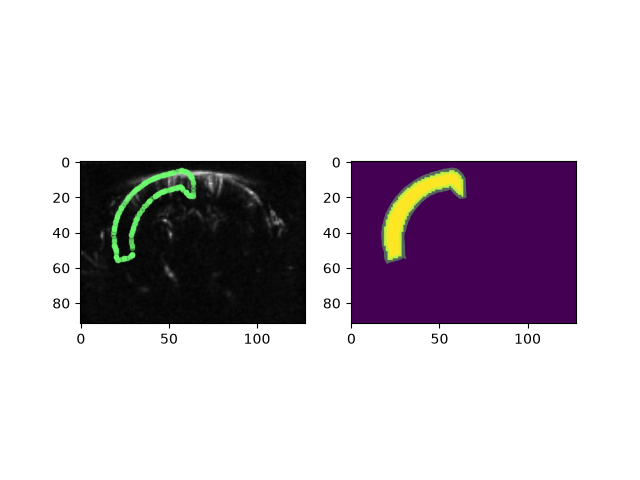

In [18]:
fig, (ax, ax2) = plt.subplots(1, 2)
im = ax.imshow(norm_voxels[:, int(scan.sizeY / 2), :, int(scan.nTime / 2), 0, 0], cmap='gray', interpolation='bilinear')
current_state = {"pose": int(scan.sizeY / 2), "roiValue": 0, "nTime": int(scan.nTime / 2)}
poly_artist = {"poly": None, "poly2": None, "poly3": None}


def update(nTime, pose, roiValue):
    current_state["pose"], current_state["roiValue"], current_state["nTime"] = pose, roiValue, nTime
    img_slice = norm_voxels[:, pose, :, nTime, 0, 0]
    im.set_data(img_slice)
    im.set_extent([-0.5, img_slice.shape[1] - 0.5, img_slice.shape[0] - 0.5, -0.5])
    
 
    if poly_artist["poly"] is not None:
        poly_artist["poly"] = None
    if poly_artist["poly3"] is not None:
        poly_artist["poly3"].remove()
        poly_artist["poly3"] = None
    if poly_artist["poly2"] is not None:
        poly_artist["poly2"].remove()
        poly_artist["poly2"] = None
    selectedRoi = roi.list[roiValue]
    selectedRoi.vertices = transformed_cache[roiValue]

    contour = roi_contour_cache[(roiValue, pose)]
    if contour is not None:
        color = (selectedRoi.color.r, selectedRoi.color.g, selectedRoi.color.b, 0.4)
        contour_x = contour[:, 0]
        contour_y = contour[:, 1]
        poly_artist["poly3"] = ax.scatter(contour_x, contour_y, marker='.', c=[color])
        


        mask = roi_mask_cache[(roiValue, pose)]
        poly_artist["poly"] = mask.T
        ax2.imshow(poly_artist["poly"])
        hull_pts = roi_hull_cache[(roiValue, pose)]
        hull_xy = hull_pts[:, :]
        poly_artist["poly2"] = Polygon(hull_xy, closed=True, fill=False,
                                        edgecolor=color, linewidth=4)
        ax2.add_patch(poly_artist["poly2"])
    fig.canvas.draw_idle()

 
interact(
    update,
    nTime=widgets.IntSlider(value=int(scan.nTime / 2), min=0, max=scan.nTime - 1, step=1),
    pose=widgets.IntSlider(value=int(scan.sizeY / 2), min=0, max=scan.sizeY - 1, step=1),
    roiValue=widgets.Dropdown(
        options = [(roi.list[i].name, i) for i in range(len(roi.list))],
        value = 0,
        description = "ROI: ",
    )
)


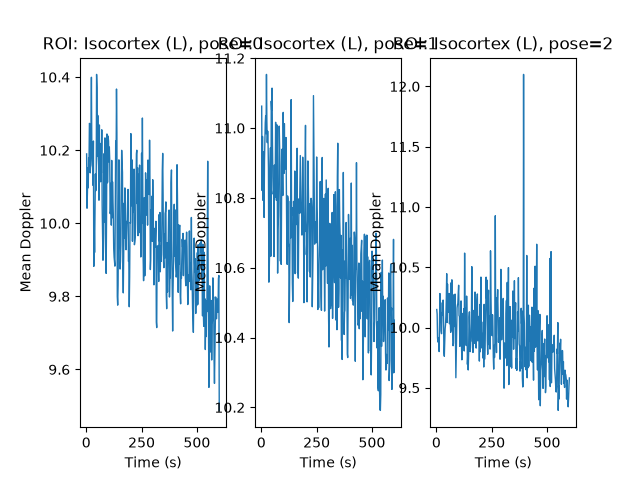

In [19]:
pose = current_state["pose"]
roiValue = current_state["roiValue"]

fig_time, ax_time = plt.subplots(1, scan.voxels.shape[1])
for i in range(scan.voxels.shape[1]):
    selectedRoi = roi.list[roiValue]
    if roiValue not in transformed_cache:
        transformed_cache[roiValue] = apply_transform(selectedRoi.vertices, Brain2Voxel)
    selectedRoi.vertices = transformed_cache[roiValue]
    title = ax_time[i].set_title(f"ROI volume: {volume(selectedRoi):.2f}")

    mask = roi_mask_cache[(roiValue, i)]
    data_over_time = norm_voxels[:, i, :, :, 0, 0]
    data_over_time = np.transpose(data_over_time, axes=(1, 0, 2))
    roiSignal = (data_over_time * mask[:, :, None]).sum(axis=(0, 1)) / mask.sum()


    ax_time[i].plot(measuredTimeVolumic, roiSignal, linewidth=1)
    ax_time[i].set_xlabel('Time (s)')
    ax_time[i].set_ylabel('Mean Doppler')
    ax_time[i].set_title(f'ROI: {selectedRoi.name}, pose={i}')
fig_time.canvas.draw_idle()

In [ ]:
# Compute the mean of every slice to have the volumic mean doppler by the time
# Connectivity = Pearson correlation between two ROIs ((L), (R))


mask = np.stack([roi_mask_cache[(roiValue, 2)], roi_mask_cache[(roiValue, 2)], roi_mask_cache[(roiValue, 2)]])
mask.shape

ValueError: all input arrays must have the same shape